#Atividade I - Análise Exploratória

-Adilson Pinheiro dos Santos

-Leonardo Medeiros de Freitas

-Caio de Godoy e Vasconcelos Galvão

-Maria Eduarda Falcão Feledi

In [1]:
import sys
import subprocess
import importlib.util
from pathlib import Path
import re
import unicodedata
import warnings
import kagglehub

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

/Users/aps/Python_APS/Python_ativ2/st-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = Path(kagglehub.dataset_download("newbie2016/dog-and-cat-data"))

arquivo = next(dataset_path.rglob("*.xlsx"))

df = pd.read_excel(arquivo)

print(f"Dimensão do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.head())

Dimensão do dataset: 486 linhas x 68 colunas


,breed_name,species,alt_names,origin_country,height,weight,life_span,personality_traits,description,adaptability,affection_level,child_friendly,dog_friendly,energy_level,grooming,health_issues,intelligence,shedding_level,social_needs,stranger_friendly,vocalisation,hypoallergenic,wikipedia_url,senior_friendly,urban_friendly,family_compatibility_score,social_environment_score,child_friendly_norm,stranger_friendly_norm,dog_friendly_norm,energy_level_norm,vocalisation_norm,affection_level_norm,intelligence_norm,adaptability_norm,senior_friendly_norm,urban_friendly_norm,senior_friendly_label,urban_friendly_label,family_compatibility_label,social_environment_label,breed_cluster,recommendation,recommendation_confidence,multi_cluster_membership,persona_match,persona_explainability_text,heat_tolerance,cold_tolerance,humidity_tolerance,all_weather_adaptability,recommended_climate_types,dietary_sensitivity_level,common_food_allergies,digestion_robustness,obesity_prone,recommended_diet_type,climate_data_source,diet_data_source,guardian_note,Avg monthly_food_cost_inr,Avg exercise_minutes_daily,Avg grooming_hours_monthly,Avg social_interaction_hours_daily,Avg total_daily_time_hours,Avg professional_grooming_cost_monthly,Avg vet_cost_monthly_avg,Avg total_monthly_cost_inr
0,Afador,Dog,Afghan Lab,United States,56-66 cm,25-32 kg,10-12 years,"Loyal, Energetic, Intelligent, Active, Friendly",A cross between Afghan Hound and Labrador Retr...,2.4000,4,2,3,4,2,3,5,4,3.0000,1,4,0,https://en.wikipedia.org/wiki/Dog_crossbreed,2.6000,2.4000,46,51.2000,0.2500,0.0000,0.5000,0.7500,0.7500,0.7500,1.0000,0.3500,0.3514,0.1538,Moderate,Moderate,Moderate,Moderate,Guard / Watch Dog,Great for active owners; Good as a guard or al...,90.0000,"Guard / Watch Dog, Active / Outdoor Dog",Security-conscious owner,Lower stranger tolerance and higher alertness ...,3,3,3,60,Temperate,2,Minimal (Generally robust),3,Medium,Balanced,archetype,archetype,Designer/mixed breed - traits can vary based o...,6700,75,10.0000,4.5000,6.5000,2300,1200,11200
1,Affenhuahua,Dog,NaN,United States,15-23 cm,2-5 kg,12-16 years,"Playful, Affectionate, Alert, Confident",A designer breed crossing Affenpinscher and Ch...,3.0000,4,3,2,4,4,4,3,2,3.0000,2,4,0,https://en.wikipedia.org/wiki/Dog_crossbreed,2.6000,2.2000,57,47.0000,0.5000,0.2500,0.2500,0.7500,0.7500,0.7500,0.5000,0.5000,0.3514,0.0769,Moderate,Moderate,Moderate,Moderate,Guard / Watch Dog,Great for active owners; Good as a guard or al...,80.0000,"Guard / Watch Dog, Active / Outdoor Dog",Security-conscious owner,Lower stranger tolerance and higher alertness ...,3,3,3,60,Temperate,3,"Corn, wheat, chicken (in sensitive individuals)",3,Medium,"Small-breed formula, Small kibble",archetype,archetype,⚠️ Health considerations: Breed prone to multi...,800,75,3.0000,4.5000,6.5000,200,800,2000
2,Affenpinscher,Dog,Monkey Dog,Germany,23-30 cm,3-4 kg,12-14 years,"Confident, Fearless, Stubborn, Active, Adventu...",A toy terrier breed with monkey-like facial fe...,3.2000,5,1,4,4,3,4,4,1,3.3300,3,2,1,https://en.wikipedia.org/wiki/Affenpinscher,3.5000,3.3000,52,71.6000,0.0000,0.5000,0.7500,0.7500,0.2500,1.0000,0.7500,0.5500,0.5946,0.5000,Good,Good,Moderate,Good,Active / Outdoor Dog,Great for active owners,80.0000,Active / Outdoor Dog,Active outdoor enthusiast,High energy levels and strong adaptability mak...,3,3,3,60,Temperate,3,"Corn, wheat, chicken (in sensitive individuals)",3,Medium,"Small-breed formula, Small kibble",archetype,archetype,⚠️ Health considerations: Breed prone to multi...,800,75,4.0000,6.0000,8.0000,600,800,2400
3,Afghan Hound,Dog,Tazi,Afghanistan,61-74 cm,20-27 kg,12-14 years,"Aloof, Clownish, Dignified, Independent, Happy","An elegant sighthound with a silky coat, bred ...",4.0000,5,5,4,5,1,3,4,4,4.6700,2,2,1,https://en.wikipedia.org/wiki/Afghan_Hound,3.1000,2.8000,72,68.0000,1.0000,0.2500,0.7500,1.0000,0.2500,1.0000,0.7500,0.7500,0.4865,0.3077,Moderate,Moderate,Good,Good,Active / Outdoor Dog,Great for active owners; Good as a guard or 

## **. Apresentação dos Dados**

Este dataset contém informações detalhadas sobre 486 raças de animais (cães e gatos), distribuídas 68 variáveis. A base de dados é extremamente rica e praticamente completa: com exceção da coluna de nomes alternativos (alt_names), todas as outras variáveis possuem 100% de preenchimento (nenhum valor nulo).

Para facilitar o entendimento durante as análises, dividimos as características mapeadas em 5 grandes blocos lógicos:

1. Identificação e Física: Dados básicos e medidas corporais.
`breed_name`, `species`, `alt_names`, `origin_country`, `height`, `weight`, `life_span`.

2. Comportamento e Socialização: Avaliações (geralmente notas de 1 a 5) sobre a personalidade do pet. `adaptability`, `affection_level`, `child_friendly`, `dog_friendly`, `energy_level`, `intelligence`, `shedding_level`, `social_needs`, `stranger_friendly`, `vocalisation`, `personality_traits`, `description`.

3. Métricas de Recomendação e Agrupamento: Scores calculados, dados normalizados (terminados em _norm), rótulos de perfil (terminados em _label) e dados do modelo de recomendação. `family_compatibility_score`, `urban_friendly`, `senior_friendly`, `breed_cluster`, `recommendation`, `persona_match`, e todas as variáveis com os sufixos _norm e _label.

4. Clima, Saúde e Dieta: Condições fisiológicas, ambientais e alimentares. `heat_tolerance`, `cold_tolerance`, `humidity_tolerance`, `all_weather_adaptability`, `health_issues`, `hypoallergenic`, `obesity_prone`, `dietary_sensitivity_level`, `common_food_allergies`, `recommended_diet_type`.

5. Esforço e Custos (INR): Variáveis quantitativas de tempo investido (em minutos/horas) e dinheiro gasto (Rúpias Indianas). `Avg exercise_minutes_daily`, `Avg grooming_hours_monthly`, `Avg social_interaction_hours_daily`, `Avg total_monthly_cost_inr`, `Avg vet_cost_monthly_avg`, `Avg monthly_food_cost_inr`, `Avg professional_grooming_cost_monthly`.

In [3]:
limite_original = pd.get_option('display.max_rows')
pd.set_option('display.max_rows', None)

resumo_dados = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Valores Preenchidos': df.notna().sum(),
    'Valores Ausentes': df.isna().sum(),
    '% Ausente': (df.isna().sum() / len(df) * 100).round(2),
    'Valores Únicos': df.nunique()
})

print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas\n")
display(resumo_dados)

pd.set_option('display.max_rows', limite_original)

Dimensões do dataset: 486 linhas e 68 colunas



,Tipo de Dado,Valores Preenchidos,Valores Ausentes,% Ausente,Valores Únicos
breed_name,str,486,0,0.0000,486
species,str,486,0,0.0000,2
alt_names,str,195,291,59.8800,192
origin_country,str,486,0,0.0000,59
height,str,486,0,0.0000,212
weight,str,486,0,0.0000,201
life_span,str,486,0,0.0000,54
personality_traits,str,486,0,0.0000,468
description,str,486,0,0.0000,484
adaptability,float64,486,0,0.0000,17


## **. Tratamento e Auditoria dos Dados**

Para garantir que nossas análises e cruzamentos funcionem perfeitamente, precisamos realizar duas etapas de higienização na base:

1. Checagem de Duplicatas e NA: Vamos confirmar se não existem registros acidentalmente duplicados na base (linhas 100% idênticas) ou se a mesma raça foi cadastrada mais de uma vez para a mesma espécie, ou se tem NA.

2. Normalização de Textos (Categorias): Variáveis de texto escritas por humanos ou extraídas de diferentes fontes podem vir com inconsistências invisíveis a olho nu, como "Dog", "DOG", " Dog " ou "dog". Para o Python, todas essas são categorias diferentes. Para evitar isso, criamos uma função que remove espaços em branco extras, tira acentos e transforma tudo em letras minúsculas, garantindo uma categorização à prova de erros. O resultado será salvo em novas colunas com o sufixo .

In [4]:
duplicadas_totais = df.duplicated().sum()
print(f'Linhas totalmente repetidas: {duplicadas_totais}')

duplicadas_raca = df.duplicated(subset=['breed_name', 'species']).sum()
print(f'Raças duplicadas (mesmo nome e espécie): {duplicadas_raca}\n')

def normalizar_texto(valor):
    if pd.isna(valor):
        return ''
    valor = str(valor)
    valor = unicodedata.normalize('NFKD', valor)
    valor = ''.join(c for c in valor if not unicodedata.combining(c))
    return valor.strip().lower()

colunas_para_limpar = [
    'species',
    'obesity_prone',
    'urban_friendly_label',
    'family_compatibility_label'
]

for coluna in colunas_para_limpar:
    if coluna in df.columns:
        df[coluna] = df[coluna].map(normalizar_texto)
        print(f'{coluna}: {sorted(df[coluna].unique())}')

# Drop de linhas com NA em qualquer coluna
antes = len(df)
df = df.dropna()
depois = len(df)
print(f'\nLinhas removidas por NA: {antes - depois}')
print(f'Shape final: {df.shape}')

Linhas totalmente repetidas: 0
Raças duplicadas (mesmo nome e espécie): 0

species: ['cat', 'dog']
obesity_prone: ['high', 'low', 'medium', 'very high']
urban_friendly_label: ['excellent', 'good', 'moderate', 'poor']
family_compatibility_label: ['excellent', 'good', 'moderate', 'poor']

Linhas removidas por NA: 291
Shape final: (195, 68)


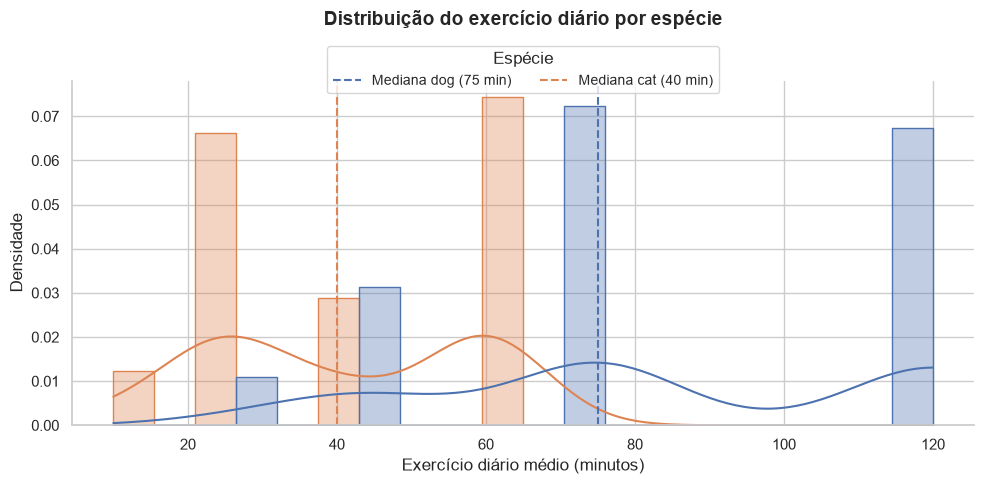

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

palette = {"dog": "#4C72B0", "cat": "#DD8452"}

sns.histplot(
    data=df,
    x='Avg exercise_minutes_daily',
    hue='species',
    bins=20,
    kde=True,
    stat='density',
    common_norm=False,
    element='step',
    alpha=0.35,
    palette=palette,
    ax=ax,
)

for especie, cor in palette.items():
    mediana = df[df['species'] == especie]['Avg exercise_minutes_daily'].median()
    ax.axvline(mediana, color=cor, linestyle='--', linewidth=1.5,
               label=f'Mediana {especie} ({mediana:.0f} min)')

ax.set_xlabel('Exercício diário médio (minutos)', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.set_title('Distribuição do exercício diário por espécie', fontsize=14,
             fontweight='bold', pad=40)  # pad abre espaço abaixo do título

ax.legend(
    title='Espécie',
    fontsize=10,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),  # centralizado, logo abaixo do título
    ncol=2,                       # itens lado a lado para ocupar menos altura
    frameon=True,
)

sns.despine()
plt.tight_layout()
plt.show()

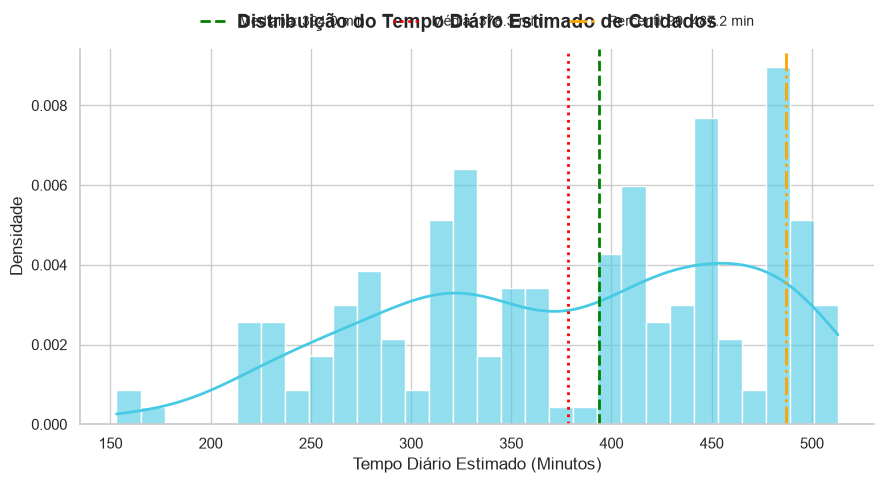

In [ ]:
df['estimated_daily_care_minutes'] = (
    df['Avg exercise_minutes_daily']
    + 60 * df['Avg social_interaction_hours_daily']
    + 2 * df['Avg grooming_hours_monthly']
)

media = df['estimated_daily_care_minutes'].mean()
mediana = df['estimated_daily_care_minutes'].median()
p90 = df['estimated_daily_care_minutes'].quantile(0.90)

plt.figure(figsize=(9, 5))

ax = sns.histplot(
    df['estimated_daily_care_minutes'],
    bins=30,
    stat='density',
    kde=True,
    color='#48cae4',
    alpha=0.6,
    line_kws={'linewidth': 2, 'color': '#03045e'},
)

plt.axvline(
    mediana,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: {mediana:.1f} min',
)
plt.axvline(
    media,
    color='red',
    linestyle=':',
    linewidth=2,
    label=f'Média: {media:.1f} min',
)
plt.axvline(
    p90,
    color='orange',
    linestyle='-.',
    linewidth=2,
    label=f'Percentil 90: {p90:.1f} min',
)

plt.title(
    'Distribuição do Tempo Diário Estimado de Cuidados',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Tempo Diário Estimado (Minutos)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

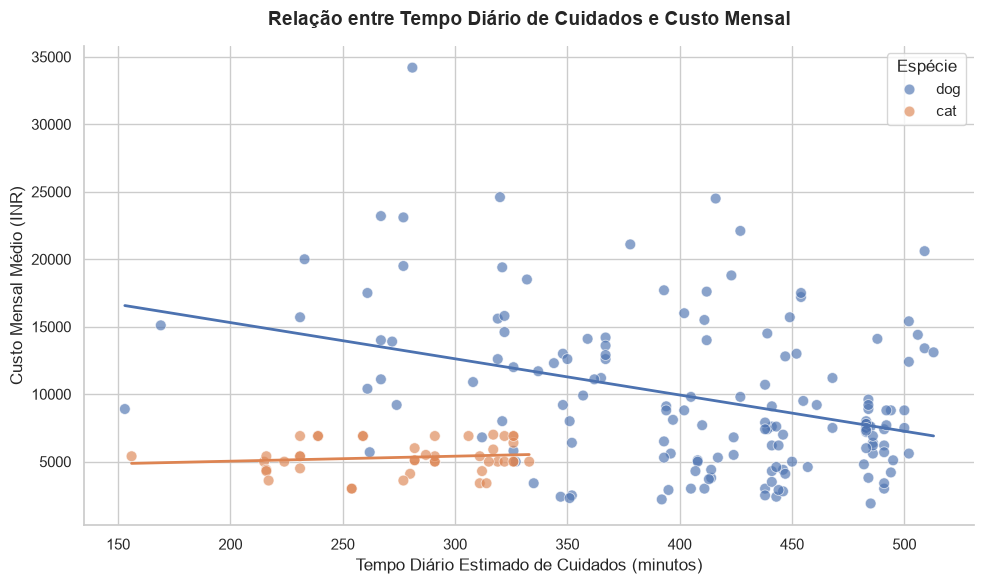

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {"dog": "#4C72B0", "cat": "#DD8452"}

sns.scatterplot(
    data=df,
    x='estimated_daily_care_minutes',
    y='Avg total_monthly_cost_inr',
    hue='species',
    palette=palette,
    alpha=0.65,
    s=60,
    ax=ax
)

for especie, cor in palette.items():
    dados_especie = df[df['species'] == especie]

    sns.regplot(
        data=dados_especie,
        x='estimated_daily_care_minutes',
        y='Avg total_monthly_cost_inr',
        scatter=False,
        ci=None,
        color=cor,
        line_kws={'linewidth': 2},
        ax=ax
    )

ax.set_title(
    'Relação entre Tempo Diário de Cuidados e Custo Mensal',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Tempo Diário Estimado de Cuidados (minutos)', fontsize=12)
ax.set_ylabel('Custo Mensal Médio (INR)', fontsize=12)

ax.legend(title='Espécie')

sns.despine()
plt.tight_layout()
plt.show()

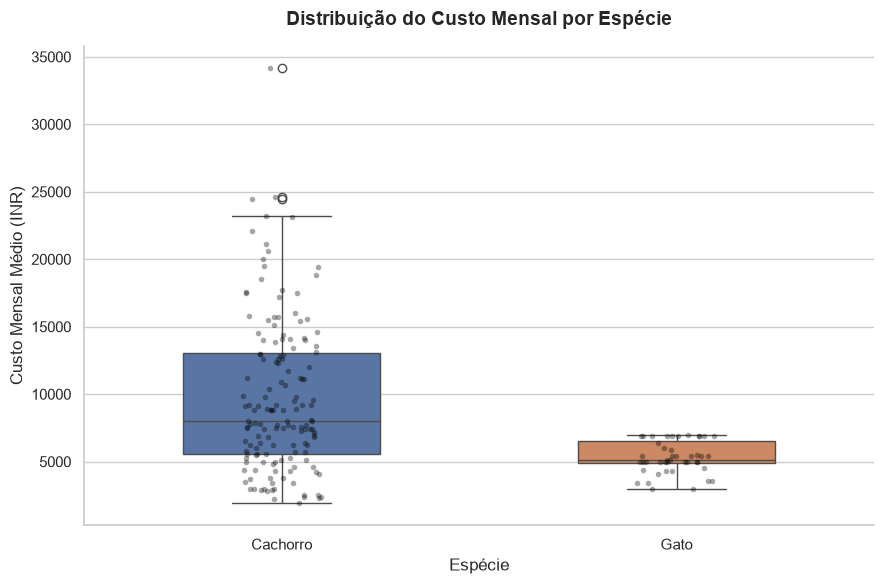

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

palette = {"dog": "#4C72B0", "cat": "#DD8452"}

sns.boxplot(
    data=df,
    x='species',
    y='Avg total_monthly_cost_inr',
    hue='species',
    palette=palette,
    width=0.5,
    legend=False,
    ax=ax
)

sns.stripplot(
    data=df,
    x='species',
    y='Avg total_monthly_cost_inr',
    color='black',
    alpha=0.35,
    size=4,
    jitter=True,
    ax=ax
)

ax.set_title(
    'Distribuição do Custo Mensal por Espécie',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Espécie', fontsize=12)
ax.set_ylabel('Custo Mensal Médio (INR)', fontsize=12)

ax.set_xticklabels(['Cachorro', 'Gato'])

sns.despine()
plt.tight_layout()
plt.show()